In [108]:
from time import time

import matplotlib.pyplot as plt
import numpy as np
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
)
from hetero_isas.monodromy_lp.decomposer import MonodromyLPDecomposerResult
from hetero_isas.monodromy_lp.invariants import recover_local_equivalence
from hetero_isas.monodromy_lp.isa import ISAHandler
from hetero_isas.monodromy_lp.mono_lp_result import plot_histograms
from hetero_isas.zz_parallel_drive.ansatz import BasicCircuitAnsatz
from numpy.random import Philox
from qiskit import QuantumCircuit
from qiskit.circuit import Gate, Parameter
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qiskit.synthesis.two_qubit.local_invariance import two_qubit_local_invariants
from qutip import Qobj
from tqdm.notebook import tqdm
from weylchamber import c1c2c3
from hetero_isas.monodromy_lp.gate import MonodromyLPGate

generator = Philox(0)

%matplotlib inline

In [109]:
# what happens if we are allowed to precompute the volumes
# can scrap the integrality part of the LP solve
# because just ask if (rho)/target is contained inside of volume

isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
        # CXGate().power(1 / 4),
        # CXGate().power(1 / 5),
    ],
    [1.0, 1 / 2, 1 / 3, 1 / 4, 1 / 5],
    ["cx", "sq[2]cx", "sq[3]cx", "sq[4]cx", "sq[5]cx"],
    compute_coverage_set=True,
)

scipy_decomposer = MonodromyLPDecomposer(
    isa_handler, use_ordered_sequences=True, include_rho_target=False
)

Building coverage,... this operation is slow.


(np.float64(0.5), np.float64(0.5), np.float64(0.5))


Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.00000000e+00-1.66533454e-16j  4.19671548e-10+2.63237193e-09j
   1.61006491e-15+2.31613287e-16j  4.56753459e-18-6.31194175e-09j]
 [-5.15473974e-16-3.40494504e-16j  2.78141161e-17+2.61600186e-09j
   1.00000000e+00+1.11022302e-16j -4.19671076e-10-2.63237171e-09j]
 [-4.19671242e-10+2.63237160e-09j  1.00000000e+00-5.55111512e-16j
  -9.00497111e-17+2.61600187e-09j -1.59793963e-15+7.85350879e-16j]
 [-2.32465827e-17-6.31194176e-09j  1.25273790e-15-6.07256855e-17j
   4.19671714e-10-2.63237165e-09j  1.00000000e+00-3.33066907e-16j]]

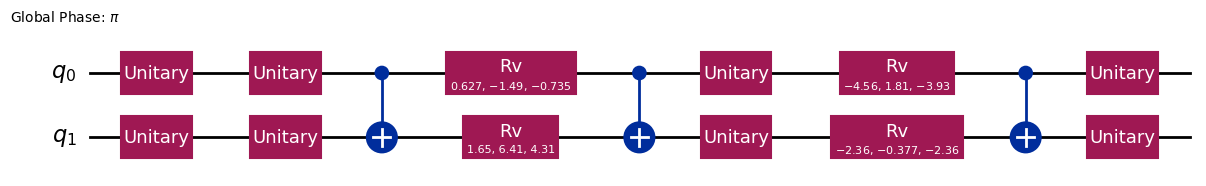

In [110]:
result = scipy_decomposer(SwapGate())
# result = decomposer(random_unitary(4).to_matrix())
result_u = Operator(result).data
print(c1c2c3(result_u))
display(Qobj(result_u))  # inspect for correctness
result.draw("mpl");

In [115]:
mono1_durations = []
# result_list = []
for _ in tqdm(range(N := 1_000)):
    time_start = time()
    target_gate = random_unitary(4).to_matrix()
    output_qc = scipy_decomposer(target_gate)  # , debugging=True)
    mono1_durations.append(time() - time_start)
    # result_list.append(lp_result)

  0%|          | 0/1000 [00:00<?, ?it/s]

NumericDecompConvergenceWarning: Failed to converge to solution within precision tolerance. If allowed,             by NumericalDecomposer.allow_fail, will return best solution instead.

In [ ]:
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
        # CXGate().power(1 / 4),
        # CXGate().power(1 / 5),
    ],
    [1.0, 1 / 2, 1 / 3, 1 / 4, 1 / 5],
    ["cx", "sq[2]cx", "sq[3]cx", "sq[4]cx", "sq[5]cx"],
    compute_coverage_set=False,
)

slower_decomposer = MonodromyLPDecomposer(
    isa_handler, use_ordered_sequences=True, include_rho_target=True
)

In [ ]:
mono2_durations = []
# result_list = []
for _ in tqdm(range(N := 1_000)):
    time_start = time()
    target_gate = random_unitary(4).to_matrix()
    _, _ = slower_decomposer(target_gate, debugging=True)
    mono2_durations.append(time() - time_start)
    # result_list.append(lp_result)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
# # print some things that we might care about :)
# print(result_list[1])
# print(np.mean([np.mean(result.total_nfev) for result in result_list]))
# print(np.mean([result.lp_calls for result in result_list]))
# print(np.mean([np.max(result.restarts) for result in result_list]))
# print(np.max([np.max(result.restarts) for result in result_list]))
# print(np.max([np.max(result.total_nfev) for result in result_list]))
# print(np.mean([np.max(result.success_nfev) for result in result_list]))
# plot_histograms(result_list)

In [ ]:
from qiskit.synthesis.two_qubit.xx_decompose import XXDecomposer

basis_fidelities = {
    np.pi / 2: 1.0,  # cx
    np.pi / 4: 1.0,  # cx^(1/2)
    np.pi / 6: 1.0,  # cx^(1/3)
    # np.pi / 8: 1.0,  # cx^(1/4)
    # np.pi / 10: 1.0,  # cx^(1/5)
    # np.pi / 12: 1.0,  # cx^(1/6)
    # np.pi / 14: 1.0,  # cx^(1/7)
    # np.pi / 16: 1.0,  # cx^(1/8)
    # np.pi / 18: 1.0,  # cx^(1/9)
}

xx_durations = []
xx_decomposer = XXDecomposer(basis_fidelities)  # basis_fidelity=strengths)
for _ in tqdm(range(N)):
    start_time = time()
    target_gate = random_unitary(4).to_matrix()
    decomp = xx_decomposer(target_gate)
    xx_durations.append(time() - start_time)

  0%|          | 0/1000 [00:00<?, ?it/s]

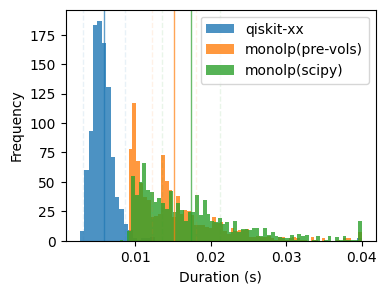

In [ ]:
# duration historams
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
bins = 64
amax = 0.04

cmap = plt.colormaps.get_cmap("tab10")

# histogram data and colors
data = [
    (xx_durations, "qiskit-xx"),
    (mono1_durations, "monolp(pre-vols)"),
    # (mono2_durations, "monolp(scipy)"),
]

for (durations, label), color in zip(data, cmap.colors):
    clipped_data = np.clip(durations, a_min=0, a_max=amax)
    ax.hist(clipped_data, bins, label=label, alpha=0.8, color=color)
    mean = np.mean(durations)
    std = np.std(durations)

    ax.axvline(mean, color=color, linestyle="-", linewidth=1, alpha=0.7)
    ax.axvline(mean + std / 2.0, color=color, linestyle="--", linewidth=1, alpha=0.1)
    ax.axvline(mean - std / 2.0, color=color, linestyle="--", linewidth=1, alpha=0.1)

ax.set_ylabel("Frequency")
ax.set_xlabel("Duration (s)")
ax.legend()

In [ ]:
%reload_ext snakeviz
import cProfile

# cProfile.run(
#     "scipy_decomposer(SwapGate())",
#     "../../../docs/profile_timings/tempa.prof",
# )

# def bench(X):
#     for _ in range(X):
#         target_gate = MonodromyLPGate.from_unitary(random_unitary(4).to_matrix())
#         gate_sequence = [
#             coverage_lookup_decomposition(
#                 isa_handler.coverage_set, target_gate.logspec
#             ).instructions
#         ]


def bench(X):
    for _ in range(X):
        target_gate = random_unitary(4).to_matrix()
        output_qc, lp_result = scipy_decomposer(target_gate, debugging=True)


cProfile.run(
    "bench(100)",
    "../../../docs/profile_timings/tempf.prof",
)

In [ ]:
# x = MonodromyLPGate.from_unitary(iSwapGate())
# # x = x.rho_reflect()
# xv = np.array(x.definition)
# xv = xv.reshape((len(xv), 1))

# epsilon = 1e-6  # Fraction(1, 1_000_000)

# # Usage example:
# # coverage_set = [CircuitPolytope([ConvexSubpolytope(np.array(...), np.array(...)), ...]), ...]
# ineq_matrix, eq_matrix, subpolytope_to_ineq, subpolytope_to_eq = (
#     preprocess_coverage_set(isa_handler.coverage_set)
# )
# valid_subpolytopes = evaluate_constraints(
#     xv, ineq_matrix, eq_matrix, subpolytope_to_ineq, subpolytope_to_eq
# )
# # print(f"Valid subpolytopes: {valid_subpolytopes}")

# isa_handler.coverage_set[min(valid_subpolytopes)[0]]

In [ ]:
# from monodromy.static.examples import exactly
# from monodromy.coordinates import rho_reflect
# from fractions import Fraction

# swap_target = MonodromyLPGate.from_unitary(SwapGate().to_matrix())
# swap_polytope = exactly(
#     *(Fraction(x).limit_denominator(10_000) for x in swap_target.definition)
# )
# swap_polytope.vertices
# rho_reflect(swap_polytope).vertices
# isa_handler.coverage_set[-1].has_element(swap_target.rho_reflect().definition)
# rho_reflect(isa_handler.coverage_set[-1]).has_element(swap_target.rho_reflect().definition)
# [x.name for x in isa_handler.coverage_set[-2].instructions]